# Knowledge Graph XAI Testing & Validation

This notebook tests and validates the Knowledge Graph XAI system across multiple samples.

## Contents:
1. Setup and imports
2. Test on multiple samples
3. Validate KG paths and relationships
4. Generate batch explanations
5. Export results

In [8]:
# Setup
import sys
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

# Add paths
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, '../src')

# Import modules
from modules import CFRPKnowledgeGraph, XAIExplainer
from modules.model_architecture import TransformerRULPredictor, LSTMRULPredictor
from modules.drl_models import DDPGActor

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## 1. Load Models and Data

In [9]:
# Load scalers and data
with open('../outputs/saved_models/feature_scaler.pkl', 'rb') as f:
    feature_scaler = pickle.load(f)
with open('../outputs/saved_models/target_scaler.pkl', 'rb') as f:
    target_scaler = pickle.load(f)
with open('../outputs/saved_models/test_data.pkl', 'rb') as f:
    test_data = pickle.load(f)
    X_test = test_data['X_test']
    y_test = test_data['y_test']

# Load standard models (Transformer, LSTM)
transformer_model = TransformerRULPredictor(input_dim=20, d_model=128, nhead=8, num_layers=4, dropout=0.2).to(device)
lstm_model = LSTMRULPredictor(input_dim=20, hidden_dim=128, num_layers=3, dropout=0.2).to(device)

transformer_model.load_state_dict(torch.load('../outputs/saved_models/transformer_model.pth', map_location=device))
lstm_model.load_state_dict(torch.load('../outputs/saved_models/lstm_model.pth', map_location=device))

transformer_model.eval()
lstm_model.eval()

print("✓ Transformer and LSTM loaded")
    
ddpg_model = DDPGActor(input_dim=20, hidden_dim=128).to(device)
ddpg_model.load_state_dict(torch.load('../outputs/saved_models/ddpg_actor.pth', map_location=device))
ddpg_model.eval()

print("✓ DDPG loaded")

# Build KG and explainers
kg = CFRPKnowledgeGraph()
feature_names = ['delta_psd', 'energy', 'tof', 'mean_intensity', 'crack_density', 'mean_strain']
transformer_explainer = XAIExplainer(transformer_model, kg, feature_names, model_type='standard')
lstm_explainer = XAIExplainer(lstm_model, kg, feature_names, model_type='standard')
ddpg_explainer = XAIExplainer(ddpg_model, kg, feature_names, model_type='ddpg')

print(f"✓ Loaded {len(X_test)} test samples")
print(f"✓ Models and explainers ready")

✓ Transformer and LSTM loaded
✓ DDPG loaded
✓ Loaded 30 test samples
✓ Models and explainers ready


## 2. Test on Multiple Samples

Test explanation generation on 10 random samples.

In [10]:
# Test on 10 random samples
np.random.seed(42)
test_indices = np.random.choice(len(X_test), size=min(10, len(X_test)), replace=False)

results = []

print("Testing on 10 samples...\n")
for idx in test_indices:
    sample_sequence = X_test[idx]
    actual_rul = y_test[idx]
    
    # Transformer explanation
    t_exp = transformer_explainer.explain_prediction(sample_sequence, actual_rul, device, target_scaler)
    
    # LSTM explanation
    l_exp = lstm_explainer.explain_prediction(sample_sequence, actual_rul, device, target_scaler)
    
    result_row = {
        'sample_idx': idx,
        'actual_rul': actual_rul,
        'transformer_pred': t_exp['predicted_rul'],
        'transformer_error': t_exp['error'],
        'transformer_error_pct': t_exp['error_percent'],
        'lstm_pred': l_exp['predicted_rul'],
        'lstm_error': l_exp['error'],
        'lstm_error_pct': l_exp['error_percent'],
        'transformer_kg_explanations': len(t_exp['kg_explanations']),
        'lstm_kg_explanations': len(l_exp['kg_explanations'])
    }
    
    d_exp = ddpg_explainer.explain_prediction(sample_sequence, actual_rul, device, target_scaler)
    result_row['ddpg_pred'] = d_exp['predicted_rul']
    result_row['ddpg_error'] = d_exp['error']
    result_row['ddpg_error_pct'] = d_exp['error_percent']
    result_row['ddpg_kg_explanations'] = len(d_exp['kg_explanations'])
    print(f"Sample {idx}: Actual={actual_rul:.0f}, T={t_exp['predicted_rul']:.0f}, L={l_exp['predicted_rul']:.0f}, D={d_exp['predicted_rul']:.0f}")
    
    results.append(result_row)

# Create DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("TESTING RESULTS SUMMARY")
print("="*80)
print(results_df.to_string(index=False))
print("\n" + "="*80)

Testing on 10 samples...

Sample 27: Actual=0, T=84050, L=84689, D=0
Sample 27: Actual=0, T=84050, L=84689, D=0
Sample 15: Actual=0, T=83946, L=84392, D=0
Sample 23: Actual=0, T=84020, L=84514, D=0
Sample 17: Actual=0, T=83965, L=84379, D=0
Sample 15: Actual=0, T=83946, L=84392, D=0
Sample 23: Actual=0, T=84020, L=84514, D=0
Sample 17: Actual=0, T=83965, L=84379, D=0
Sample 8: Actual=0, T=83906, L=84473, D=0
Sample 9: Actual=0, T=83907, L=84456, D=0
Sample 8: Actual=0, T=83906, L=84473, D=0
Sample 9: Actual=0, T=83907, L=84456, D=0
Sample 28: Actual=0, T=84057, L=84724, D=0
Sample 28: Actual=0, T=84057, L=84724, D=0
Sample 24: Actual=0, T=84028, L=84562, D=0
Sample 12: Actual=0, T=83922, L=84413, D=0
Sample 24: Actual=0, T=84028, L=84562, D=0
Sample 12: Actual=0, T=83922, L=84413, D=0
Sample 0: Actual=0, T=84032, L=84393, D=0

TESTING RESULTS SUMMARY
 sample_idx  actual_rul  transformer_pred  transformer_error  transformer_error_pct    lstm_pred   lstm_error  lstm_error_pct  transforme

## 3. Validate Knowledge Graph Paths

Check KG paths and relationships for consistency.

In [11]:
# Validate KG structure
import networkx as nx

print("Knowledge Graph Validation\n" + "="*60)

# Check connectivity
print("\n1. Connectivity Check:")
print(f"   • Graph is directed: {kg.graph.is_directed()}")
print(f"   • Number of weakly connected components: {nx.number_weakly_connected_components(kg.graph)}")

# Check all features have paths to stages
print("\n2. Feature → Stage Path Validation:")
features = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'feature']
stages = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'stage']

path_matrix = []
for feature in features:
    feature_paths = []
    for stage in stages:
        has_path = nx.has_path(kg.graph, feature, stage)
        feature_paths.append(has_path)
    path_matrix.append(feature_paths)
    
# Display as DataFrame
path_df = pd.DataFrame(path_matrix, index=features, columns=stages)
print(path_df)

# Check edge attributes
print("\n3. Edge Attributes Check:")
sample_edges = list(kg.graph.edges(data=True))[:5]
for u, v, data in sample_edges:
    print(f"   • {u} → {v}")
    print(f"     - Relation: {data.get('relation', 'N/A')}")
    print(f"     - Weight: {data.get('weight', 'N/A')}")

print("\n✓ Knowledge Graph validation complete")

Knowledge Graph Validation

1. Connectivity Check:
   • Graph is directed: True
   • Number of weakly connected components: 3

2. Feature → Stage Path Validation:
                healthy  early_damage  progressive  critical
delta_psd         False          True         True     False
energy            False         False         True      True
tof               False          True         True     False
mean_intensity    False         False        False     False
crack_density     False          True         True     False
mean_strain       False         False         True     False

3. Edge Attributes Check:
   • crack_propagation → early_damage
     - Relation: N/A
     - Weight: 0.6
   • crack_propagation → progressive
     - Relation: N/A
     - Weight: 0.9
   • delamination → progressive
     - Relation: N/A
     - Weight: 0.8
   • delamination → critical
     - Relation: N/A
     - Weight: 0.95
   • fiber_breakage → critical
     - Relation: N/A
     - Weight: 1.0

✓ Knowledge Gr

## 4. Analyze Error Distribution

Compare prediction errors between models.

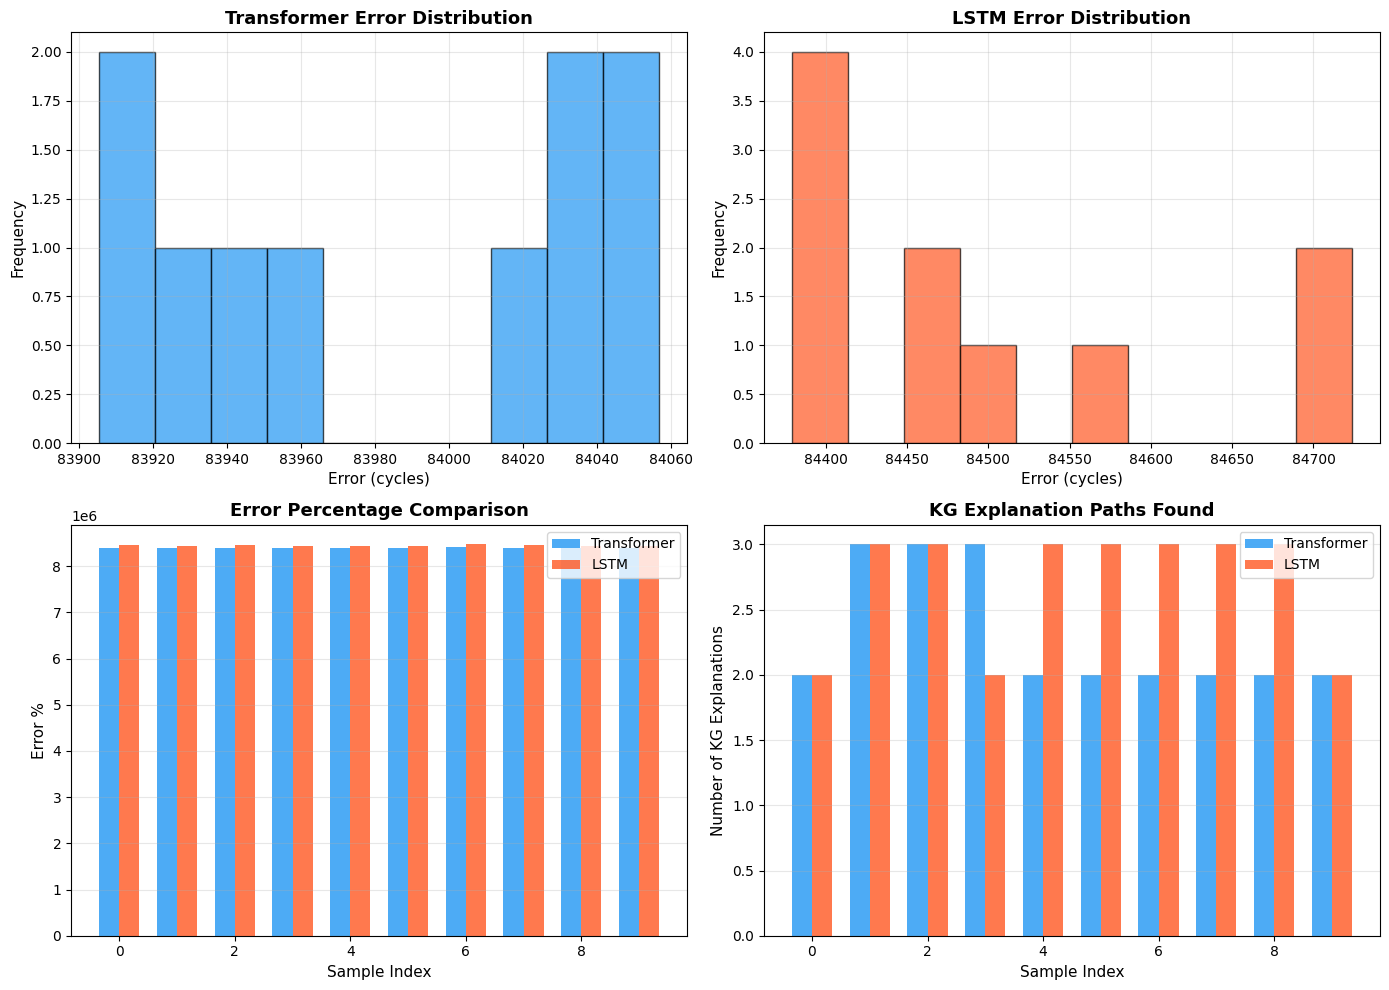


Summary Statistics:
Transformer:
  Mean Error: 83983.17 cycles
  Mean Error %: 8398317.00%
  Avg KG Explanations: 2.30

LSTM:
  Mean Error: 84499.55 cycles
  Mean Error %: 8449955.00%
  Avg KG Explanations: 2.70


In [12]:
# Error distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Error histograms
axes[0, 0].hist(results_df['transformer_error'], bins=10, color='#2196F3', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Error (cycles)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Transformer Error Distribution', fontsize=13, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(results_df['lstm_error'], bins=10, color='#FF5722', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Error (cycles)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('LSTM Error Distribution', fontsize=13, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Error percentage comparison
x = np.arange(len(results_df))
width = 0.35
axes[1, 0].bar(x - width/2, results_df['transformer_error_pct'], width, label='Transformer', color='#2196F3', alpha=0.8)
axes[1, 0].bar(x + width/2, results_df['lstm_error_pct'], width, label='LSTM', color='#FF5722', alpha=0.8)
axes[1, 0].set_xlabel('Sample Index', fontsize=11)
axes[1, 0].set_ylabel('Error %', fontsize=11)
axes[1, 0].set_title('Error Percentage Comparison', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3, axis='y')

# KG explanation count
axes[1, 1].bar(x - width/2, results_df['transformer_kg_explanations'], width, 
              label='Transformer', color='#2196F3', alpha=0.8)
axes[1, 1].bar(x + width/2, results_df['lstm_kg_explanations'], width,
              label='LSTM', color='#FF5722', alpha=0.8)
axes[1, 1].set_xlabel('Sample Index', fontsize=11)
axes[1, 1].set_ylabel('Number of KG Explanations', fontsize=11)
axes[1, 1].set_title('KG Explanation Paths Found', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary statistics
print("\nSummary Statistics:")
print("="*60)
print(f"Transformer:")
print(f"  Mean Error: {results_df['transformer_error'].mean():.2f} cycles")
print(f"  Mean Error %: {results_df['transformer_error_pct'].mean():.2f}%")
print(f"  Avg KG Explanations: {results_df['transformer_kg_explanations'].mean():.2f}")
print(f"\nLSTM:")
print(f"  Mean Error: {results_df['lstm_error'].mean():.2f} cycles")
print(f"  Mean Error %: {results_df['lstm_error_pct'].mean():.2f}%")
print(f"  Avg KG Explanations: {results_df['lstm_kg_explanations'].mean():.2f}")

## 5. Generate Batch Explanations Report

Create detailed report for all tested samples.

In [13]:
# Generate detailed report
detailed_results = []

for idx in test_indices[:5]:  # Detailed report for first 5
    sample_sequence = X_test[idx]
    actual_rul = y_test[idx]
    
    # Get explanations
    t_exp = transformer_explainer.explain_prediction(sample_sequence, actual_rul, device, target_scaler)
    l_exp = lstm_explainer.explain_prediction(sample_sequence, actual_rul, device, target_scaler)
    
    detailed_results.append({
        'Sample Index': idx,
        'Actual RUL': actual_rul,
        'Transformer Prediction': t_exp['predicted_rul'],
        'LSTM Prediction': l_exp['predicted_rul'],
        'Transformer Error %': t_exp['error_percent'],
        'LSTM Error %': l_exp['error_percent'],
        'Transformer Top Feature': t_exp['top_features'][0][0],
        'LSTM Top Feature': l_exp['top_features'][0][0],
        'Transformer KG Paths': len(t_exp['kg_explanations']),
        'LSTM KG Paths': len(l_exp['kg_explanations'])
    })

# Create detailed DataFrame
detailed_df = pd.DataFrame(detailed_results)

print("\n" + "="*80)
print("DETAILED EXPLANATION REPORT (First 5 Samples)")
print("="*80)
for _, row in detailed_df.iterrows():
    print(f"\nSample {int(row['Sample Index'])}:")
    print(f"  Actual RUL: {row['Actual RUL']:.0f} cycles")
    print(f"  Transformer: {row['Transformer Prediction']:.0f} cycles (Error: {row['Transformer Error %']:.1f}%)")
    print(f"    Top Feature: {row['Transformer Top Feature']}")
    print(f"    KG Paths: {int(row['Transformer KG Paths'])}")
    print(f"  LSTM: {row['LSTM Prediction']:.0f} cycles (Error: {row['LSTM Error %']:.1f}%)")
    print(f"    Top Feature: {row['LSTM Top Feature']}")
    print(f"    KG Paths: {int(row['LSTM KG Paths'])}")
    print("-" * 60)

print("\n✓ Batch explanation report generated")


DETAILED EXPLANATION REPORT (First 5 Samples)

Sample 27:
  Actual RUL: 0 cycles
  Transformer: 84050 cycles (Error: 8405010.0%)
    Top Feature: mean_strain
    KG Paths: 2
  LSTM: 84689 cycles (Error: 8468926.0%)
    Top Feature: crack_density
    KG Paths: 2
------------------------------------------------------------

Sample 15:
  Actual RUL: 0 cycles
  Transformer: 83946 cycles (Error: 8394632.0%)
    Top Feature: energy
    KG Paths: 3
  LSTM: 84392 cycles (Error: 8439194.0%)
    Top Feature: crack_density
    KG Paths: 3
------------------------------------------------------------

Sample 23:
  Actual RUL: 0 cycles
  Transformer: 84020 cycles (Error: 8401986.0%)
    Top Feature: mean_strain
    KG Paths: 3
  LSTM: 84514 cycles (Error: 8451444.0%)
    Top Feature: tof
    KG Paths: 3
------------------------------------------------------------

Sample 17:
  Actual RUL: 0 cycles
  Transformer: 83965 cycles (Error: 8396458.0%)
    Top Feature: tof
    KG Paths: 3
  LSTM: 84379 cyc

## 6. Export Results

Save testing results to CSV for further analysis.

In [14]:
# Export results
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_path = f'../outputs/reports/kg_xai_test_results_{timestamp}.csv'

# Ensure directory exists
Path(output_path).parent.mkdir(parents=True, exist_ok=True)

# Save to CSV
results_df.to_csv(output_path, index=False)

print(f"✓ Results exported to: {output_path}")
print(f"\nTotal samples tested: {len(results_df)}")
print(f"Average Transformer Error: {results_df['transformer_error'].mean():.2f} cycles")
print(f"Average LSTM Error: {results_df['lstm_error'].mean():.2f} cycles")
print("\n" + "="*60)
print("Testing complete!")

✓ Results exported to: ../outputs/reports/kg_xai_test_results_20251103_175806.csv

Total samples tested: 10
Average Transformer Error: 83983.17 cycles
Average LSTM Error: 84499.55 cycles

Testing complete!
